In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nav_df = pd.read_csv("../data/processed/nav_history_clean.csv")

In [3]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

In [7]:
nav_df = nav_df.sort_values(
    ['amfi_code', 'date']
)

In [9]:
nav_df['daily_return'] = (
    nav_df
    .groupby('amfi_code')['nav']
    .pct_change()
)

In [11]:
nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [13]:
nav_df['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

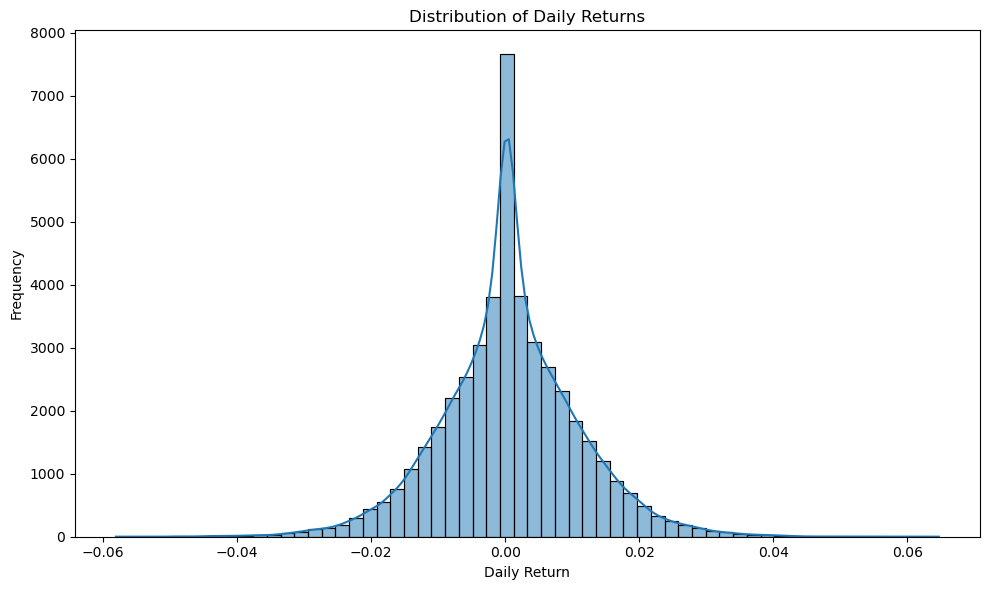

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df['daily_return'].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("../reports/daily_return_distribution.png", dpi=300)

plt.show()

In [19]:
nav_df.to_csv(
    "../data/processed/nav_daily_returns.csv",
    index=False
)

# Task 1: Daily Return Analysis

## Objective

Calculate daily returns for all mutual fund schemes using daily NAV values and analyze the distribution of returns.

### Formula

Daily Return = (NAV_today / NAV_previous_day) − 1

### Insight

Daily returns are centered around zero with relatively small fluctuations, indicating that most NAV movements are modest on a day-to-day basis. The return distribution appears approximately normal with occasional extreme positive and negative movements.

In [22]:
latest_date = nav_df['date'].max()
latest_date

Timestamp('2026-05-29 00:00:00')

In [40]:
def calculate_cagr(df, years):
    
    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    
    df_period = df[df['date'] >= start_date]

    if len(df_period) < 2:
        return np.nan

    start_nav = df_period.iloc[0]['nav']
    end_nav = df_period.iloc[-1]['nav']

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    return cagr

In [42]:
results = []

for amfi, group in nav_df.groupby('amfi_code'):
    
    group = group.sort_values('date')
    
    try:
        cagr1 = calculate_cagr(group,1)
    except:
        cagr1 = None
        
    try:
        cagr3 = calculate_cagr(group,3)
    except:
        cagr3 = None
        
    try:
        cagr5 = calculate_cagr(group,5)
    except:
        cagr5 = None
        
    results.append({
        "amfi_code":amfi,
        "CAGR_1Y":cagr1,
        "CAGR_3Y":cagr3,
        "CAGR_5Y":cagr5
    })

cagr_df = pd.DataFrame(results)

In [44]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [46]:
cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,0.222611,0.351118,0.244453
34,148567,0.203607,0.340009,0.267993
24,120504,0.130643,0.324874,0.202340
2,100033,0.532324,0.324425,0.260741
25,120505,0.296047,0.317775,0.283768
19,119551,0.604373,0.304565,0.223849
30,120843,0.266571,0.295828,0.267425
36,148569,0.397518,0.291789,0.276299
3,101206,0.479241,0.289677,0.204427
39,149324,0.651387,0.270004,0.279174


In [50]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

In [52]:
cagr_display = cagr_df.copy()

for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    cagr_display[col] = (cagr_display[col] * 100).round(2)

cagr_display.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


# Task 2: CAGR Analysis

## Objective

Calculate the Compound Annual Growth Rate (CAGR) over 1-year, 3-year, and 5-year periods for all mutual fund schemes.

### Insight

The CAGR comparison highlights the long-term growth performance of mutual funds. Funds with consistently higher CAGR values demonstrate stronger long-term returns and better wealth creation potential compared to their peers.

In [54]:
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

In [56]:
sharpe_results = []

for amfi, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 0:

        avg_return = returns.mean()
        std_return = returns.std()

        sharpe = ((avg_return - daily_rf) / std_return) * np.sqrt(252)

        sharpe_results.append({
            "amfi_code": amfi,
            "Sharpe_Ratio": sharpe
        })

sharpe_df = pd.DataFrame(sharpe_results)

In [58]:
sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [60]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


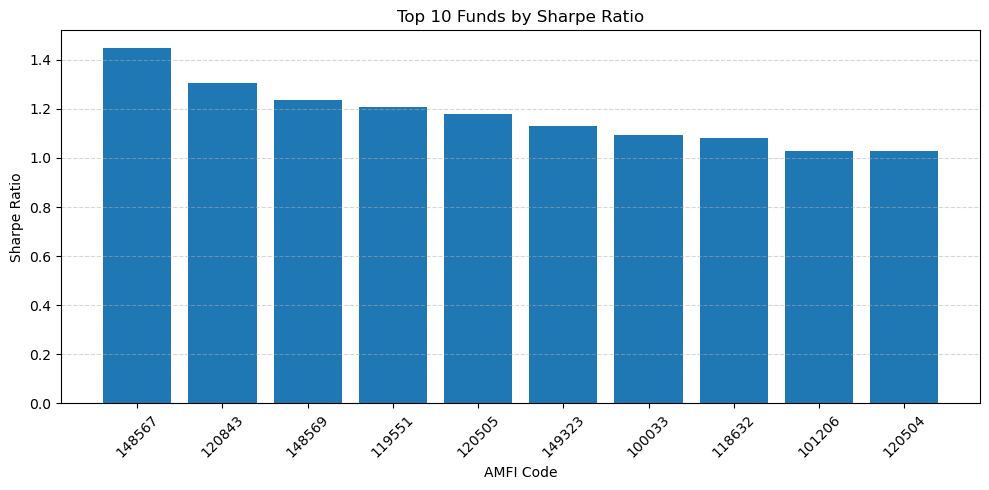

In [71]:
plt.figure(figsize=(10,5))

plt.bar(top10["amfi_code"].astype(str), top10["Sharpe_Ratio"])

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../reports/sharpe_ratio.png", dpi=300)
plt.show()

In [73]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

# Task 3: Sharpe Ratio Analysis

## Objective

Evaluate the risk-adjusted performance of mutual fund schemes using the Sharpe Ratio.

### Formula

Sharpe Ratio = ((Average Daily Return − Risk-Free Rate) / Standard Deviation) × √252

### Risk-Free Rate

6.5% per annum

### Insight

The Sharpe Ratio measures how much excess return a fund generates for each unit of risk. Funds with higher Sharpe Ratios offer better risk-adjusted performance and are generally considered more efficient investment choices.

In [75]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [77]:
sortino_results = []

for amfi, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    if len(downside_returns) > 0:

        avg_return = returns.mean()
        downside_std = downside_returns.std()

        sortino = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)

        sortino_results.append({
            "amfi_code": amfi,
            "Sortino_Ratio": sortino
        })

sortino_df = pd.DataFrame(sortino_results)

In [79]:
sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [81]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


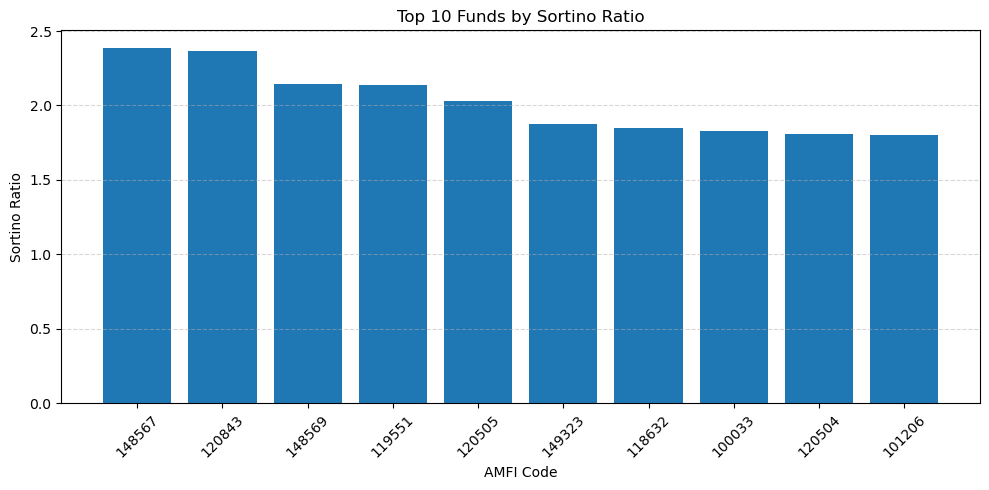

In [83]:
plt.figure(figsize=(10,5))

top10 = sortino_df.head(10)

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sortino_Ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../reports/sortino_ratio.png", dpi=300)

plt.show()

In [85]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

# Task 4: Sortino Ratio Analysis

## Objective

Evaluate the downside risk-adjusted performance of mutual fund schemes using the Sortino Ratio.

### Formula

Sortino Ratio = ((Average Daily Return − Risk-Free Rate) / Downside Standard Deviation) × √252

### Risk-Free Rate

6.5% per annum

### Insight

Unlike the Sharpe Ratio, the Sortino Ratio considers only downside volatility, making it a more focused measure of investment risk. Higher Sortino Ratios indicate funds that generate better returns while minimizing downside risk.

In [93]:
benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [95]:
benchmark_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [97]:
from scipy.stats import linregress

In [99]:
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

In [101]:
nifty100 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY100'
].copy()

In [103]:
nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [105]:
nifty100 = nifty100[
    ['date', 'benchmark_return']
]

In [107]:
merged_df = pd.merge(
    nav_df,
    nifty100,
    on='date',
    how='inner'
)

In [109]:
alpha_beta = []

for amfi, group in merged_df.groupby("amfi_code"):

    group = group.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    if len(group) > 10:

        slope, intercept, r_value, p_value, std_err = linregress(
            group["benchmark_return"],
            group["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": amfi,
            "Alpha": intercept * 252,
            "Beta": slope,
            "R_Squared": r_value ** 2
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

In [111]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [113]:
alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
).head(10)

,amfi_code,Alpha,Beta,R_Squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04


In [115]:
alpha_beta_df.sort_values(
    "Beta",
    ascending=False
).head(10)

,amfi_code,Alpha,Beta,R_Squared
11,118634,0.175007,0.103497,0.002793
22,119599,0.048824,0.062002,0.001026
32,125497,0.177298,0.048820,0.001840
26,120506,0.162539,0.041896,0.001257
28,120841,0.130429,0.036356,0.001211
15,119093,0.082328,0.025883,0.000569
34,148567,0.269838,0.023684,0.000463
3,101206,0.213998,0.021086,0.000348
36,148569,0.282704,0.018134,0.000175
29,120842,0.078044,0.018057,0.000169


In [117]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

# Task 5: Alpha & Beta Analysis

## Objective

Evaluate each mutual fund's performance relative to the NIFTY100 benchmark using Alpha and Beta.

### Method

- Benchmark: NIFTY100
- Daily returns calculated using percentage change.
- Linear regression performed using scipy.stats.linregress.

### Interpretation

- **Alpha** measures excess return generated beyond the benchmark.
- **Beta** measures sensitivity of the fund to market movements.
- A Beta greater than 1 indicates higher volatility than the benchmark, while a Beta less than 1 indicates lower market sensitivity.

### Insight

Funds with higher Alpha have generated superior returns relative to the benchmark after adjusting for market movements, while Beta helps assess the level of market risk associated with each fund.

In [120]:
max_dd_results = []

for amfi, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

In [122]:
    max_dd = group["drawdown"].min()

    worst_row = group.loc[group["drawdown"].idxmin()]

    max_dd_results.append({
        "amfi_code": amfi,
        "Maximum_Drawdown": max_dd,
        "Worst_Date": worst_row["date"]
    })

max_dd_df = pd.DataFrame(max_dd_results)

In [124]:
max_dd_df.head()

,amfi_code,Maximum_Drawdown,Worst_Date
0,149324,-0.311719,2025-01-03


In [126]:
max_dd_df.sort_values(
    "Maximum_Drawdown"
).head(10)

,amfi_code,Maximum_Drawdown,Worst_Date
0,149324,-0.311719,2025-01-03


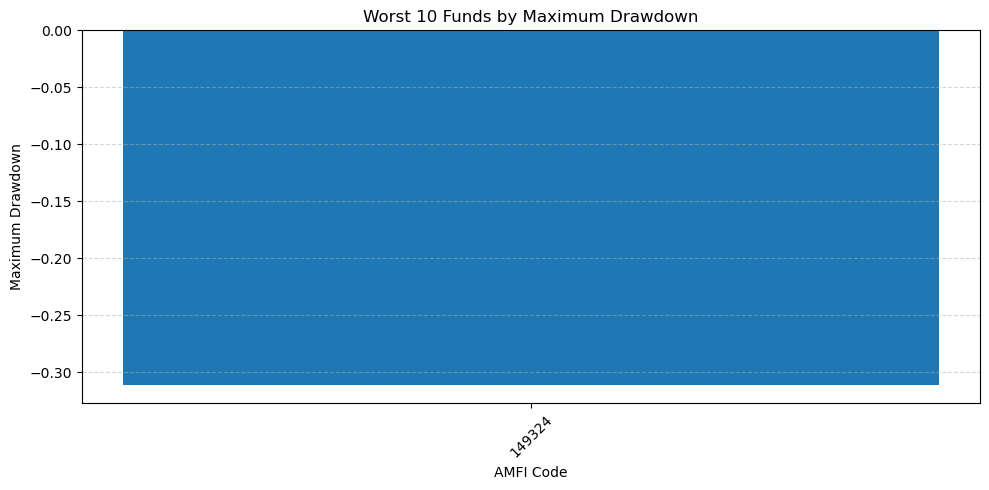

In [128]:
top10 = max_dd_df.sort_values(
    "Maximum_Drawdown"
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Maximum_Drawdown"]
)

plt.title("Worst 10 Funds by Maximum Drawdown")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("../reports/maximum_drawdown.png", dpi=300)

plt.show()

In [130]:
max_dd_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

# Task 6: Maximum Drawdown Analysis

## Objective

Calculate the Maximum Drawdown (MDD) for each mutual fund scheme to measure the largest decline from its historical peak NAV.

### Formula

Maximum Drawdown = Minimum (NAV / Running Maximum NAV − 1)

### Interpretation

- A smaller drawdown indicates better downside protection.
- A larger negative drawdown indicates higher downside risk.

### Insight

Maximum Drawdown helps identify funds that experienced significant declines during adverse market conditions. Funds with lower drawdowns generally demonstrate better resilience and capital preservation.

In [133]:
score_df = cagr_df[['amfi_code', 'CAGR_3Y']].merge(
    sharpe_df[['amfi_code', 'Sharpe_Ratio']],
    on='amfi_code'
).merge(
    alpha_beta_df[['amfi_code', 'Alpha']],
    on='amfi_code'
).merge(
    max_dd_df[['amfi_code', 'Maximum_Drawdown']],
    on='amfi_code'
)

In [135]:
score_df["CAGR_Rank"] = score_df["CAGR_3Y"].rank(ascending=False)

score_df["Sharpe_Rank"] = score_df["Sharpe_Ratio"].rank(ascending=False)

score_df["Alpha_Rank"] = score_df["Alpha"].rank(ascending=False)

# Smaller drawdown is better
score_df["Drawdown_Rank"] = score_df["Maximum_Drawdown"].rank(ascending=False)

In [137]:
max_rank = len(score_df)

score_df["Fund_Score"] = (
    (max_rank - score_df["CAGR_Rank"] + 1) / max_rank * 40 +
    (max_rank - score_df["Sharpe_Rank"] + 1) / max_rank * 30 +
    (max_rank - score_df["Alpha_Rank"] + 1) / max_rank * 20 +
    (max_rank - score_df["Drawdown_Rank"] + 1) / max_rank * 10
)

In [139]:
score_df = score_df.sort_values(
    "Fund_Score",
    ascending=False
)

score_df.head(10)

,amfi_code,CAGR_3Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Fund_Score
0,149324,0.270004,0.949796,0.300579,-0.311719,1.0,1.0,1.0,1.0,100.0


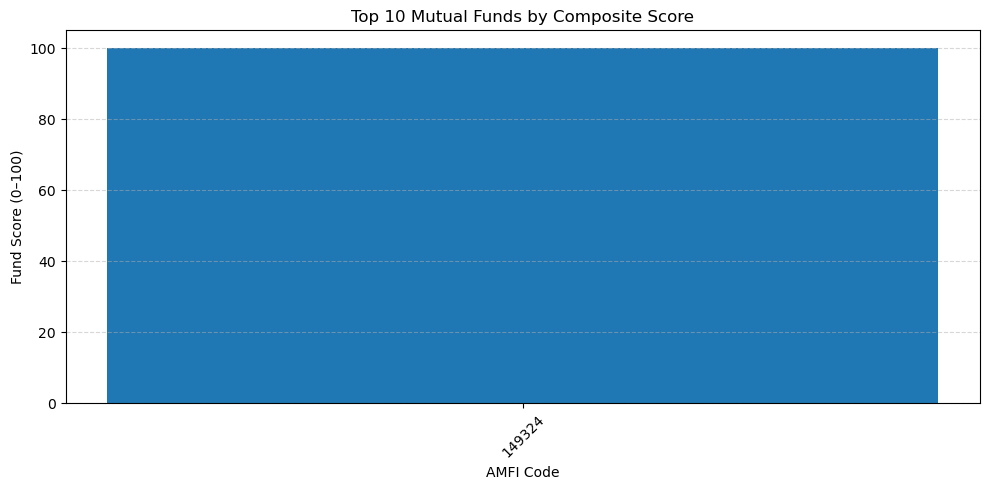

In [141]:
plt.figure(figsize=(10,5))

top10 = score_df.head(10)

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Fund_Score"]
)

plt.title("Top 10 Mutual Funds by Composite Score")
plt.xlabel("AMFI Code")
plt.ylabel("Fund Score (0–100)")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../reports/fund_scorecard.png", dpi=300)

plt.show()

In [143]:
score_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

# Task 7: Fund Scorecard

## Objective

Develop a composite score (0–100) to rank mutual funds based on multiple performance and risk metrics.

### Metrics Used

- 3-Year CAGR
- Sharpe Ratio
- Alpha
- Maximum Drawdown

### Scoring Weights

- CAGR (40%)
- Sharpe Ratio (30%)
- Alpha (20%)
- Maximum Drawdown (10%)

### Insight

The composite fund score provides an overall ranking by combining return, risk-adjusted performance, market outperformance, and downside risk into a single metric. Funds with higher scores demonstrate a stronger balance of growth and risk management.

In [146]:
top5_funds = score_df.head(5)["amfi_code"].tolist()

top5_funds

[149324]

In [148]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

In [150]:
benchmark["Normalized"] = benchmark.groupby("index_name")[
    "close_value"
].transform(lambda x: x / x.iloc[0] * 100)

In [152]:
funds = nav_df[
    nav_df["amfi_code"].isin(top5_funds)
].copy()

funds["Normalized"] = funds.groupby("amfi_code")[
    "nav"
].transform(lambda x: x / x.iloc[0] * 100)

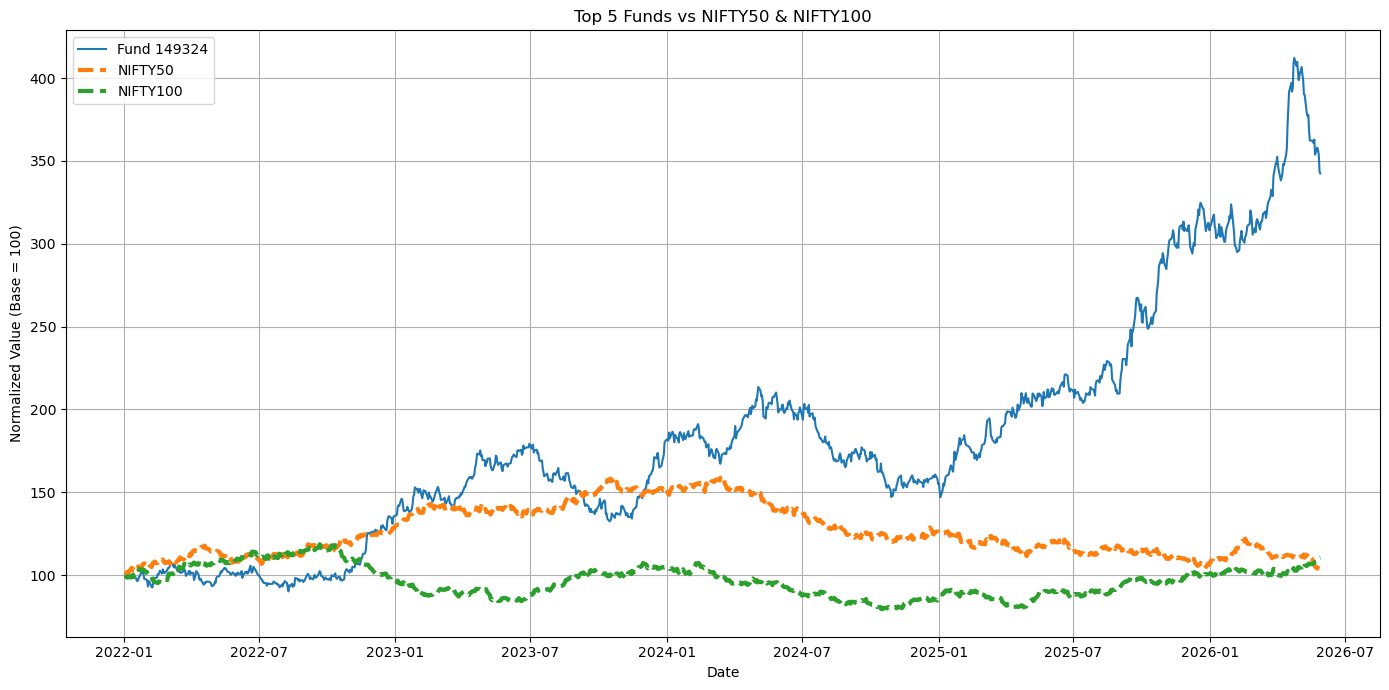

In [154]:
plt.figure(figsize=(14,7))

# Plot Funds
for fund in top5_funds:
    data = funds[funds["amfi_code"] == fund]

    plt.plot(
        data["date"],
        data["Normalized"],
        label=f"Fund {fund}"
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    data = benchmark[
        benchmark["index_name"] == idx
    ]

    plt.plot(
        data["date"],
        data["Normalized"],
        linewidth=3,
        linestyle="--",
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [156]:
benchmark_returns = benchmark_df[
    benchmark_df["index_name"]=="NIFTY100"
].copy()

benchmark_returns["date"] = pd.to_datetime(
    benchmark_returns["date"]
)

benchmark_returns = benchmark_returns.sort_values("date")

benchmark_returns["benchmark_return"] = (
    benchmark_returns["close_value"]
    .pct_change()
)

In [158]:
tracking_errors = []

for fund in top5_funds:

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        benchmark_returns[["date","benchmark_return"]],
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] -
         merged["benchmark_return"])
        .std()
    ) * np.sqrt(252)

    tracking_errors.append({
        "amfi_code": fund,
        "Tracking_Error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_errors)

In [160]:
tracking_error_df

,amfi_code,Tracking_Error
0,149324,0.27917


In [162]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

# Task 8: Benchmark Comparison

## Objective

Compare the performance of the top five mutual funds against the NIFTY50 and NIFTY100 benchmark indices.

### Methodology

- Selected the top five funds based on the composite Fund Score.
- Normalized NAV and benchmark index values to a base value of 100.
- Compared long-term performance using line charts.
- Calculated Tracking Error relative to the NIFTY100 benchmark.

### Tracking Error Formula

Tracking Error = Standard Deviation (Fund Return − Benchmark Return) × √252

### Insight

The benchmark comparison highlights how consistently each top-performing mutual fund tracks or outperforms the market indices. Lower Tracking Error indicates closer alignment with the benchmark, whereas higher Tracking Error suggests greater deviation due to active fund management.

In [167]:
git add.
git commit -m "Day 4: Fund Performance Analytics completed"
git push origin main

SyntaxError: invalid syntax (2989139957.py, line 1)